In [1]:
from pathlib import Path
import necstdb
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os

In [ ]:
FILENAME = "20250814_test_pid_elscan_kp2.3_ki0.12_kd0.2_speed1600_lon57_lat45_margin0.2"
DATE = "0814"
data_path = Path().cwd()

save_dir = Path().cwd() / Path(f"Pictures/PID/el")
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f"{FILENAME}_PID_el.png")
save_path_all = os.path.join(save_dir, f"{FILENAME}_PID_el_all_range.png")

In [8]:
data_path

PosixPath('/Users/okamoto/nanten2/202603')

In [4]:
db = necstdb.opendb(data_path / Path(FILENAME))

Exception: This directory doesn't exist!!

In [410]:
# antenna_labels = ["necst-NANTEN2-ctrl-antenna-encoder"]
antenna_labels = ["necst-NANTEN2-ctrl-antenna-encoder", "necst-NANTEN2-ctrl-antenna-altaz", ]
# antenna_labels = ["necst-OMU1P85M-ctrl-antenna-encoder"]
antenna_data = []
for index, antenna_label in enumerate(antenna_labels):
    antenna_data.append(db.open_table(antenna_label).read(astype="array"))

speed_labels = ["necst-NANTEN2-ctrl-antenna-speed", ]
speed_data = []
for index, speed_label in enumerate(speed_labels):
    speed_data.append(db.open_table(speed_label).read(astype="array"))

In [411]:
enc = antenna_data[0]["lat"]
enc_time = antenna_data[0]["time"]

cmd = antenna_data[1]["lat"]
cmd_time = antenna_data[1]["time"]

speed = speed_data[0]["el"]
time_sp = speed_data[0]["time"]
# speed_el = speed_data[1]["el"]
# time_sp = speed_data[1]["time"]

In [412]:
relative_zeropoint = enc_time[0]

In [417]:
def plot_azel(cmd, enc, range=None):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        enc_time-relative_zeropoint,
        enc,
        marker=".",
        linestyle="-",
        color="tab:blue",
        label="enc",
        alpha=0.6,
        markersize=2,
    )

    ax.plot(
        cmd_time-relative_zeropoint,
        cmd,
        marker=".",
        linestyle="-",
        color="orange",
        label="cmd",
        alpha=0.6,
        markersize=2,
    )

    ax.legend(loc="upper left")
    ax.set_title(f"{FILENAME}")
    ax.set_ylabel("El: cmd / enc [deg]")
    ax.set_xlabel("time [s]")

    ax.grid()
    if range:
        # X軸を制限
        ax.set_xlim(range[0], range[1] + 1)

        # X軸範囲内のデータを抽出してY軸のmin/maxを計算
        mask = (enc_time - relative_zeropoint >= range[0]) & (enc_time - relative_zeropoint <= range[1])
        y_min = min(enc[mask].min(), cmd[mask].min())
        y_max = max(enc[mask].max(), cmd[mask].max())

        ax.set_ylim(y_min, y_max)


# enc を cmd_time に合わせて補間
enc_interp = np.interp(cmd_time, enc_time, enc)
diff = cmd - enc_interp

# 相対時刻（秒）
t_rel = cmd_time - relative_zeropoint  

# インデックス or 時刻で開始・終了を指定
# 例：相対時刻 120[s] ～ 360[s] の間
t0, t1 = 15, 16

# マスクを作って端点インデックスを拾う
mask = (t_rel >= t0) & (t_rel <= t1)
idx0 = np.where(mask)[0][0]
idx1 = np.where(mask)[0][-1]

# dy/dx で傾きを計算
dy = cmd[idx1] - cmd[idx0]
dx = t_rel[idx1] - t_rel[idx0]
slope_deg_per_s = dy / dx

# dy/dx で傾きを計算
dy_enc = enc[idx1] - enc[idx0]
dx = t_rel[idx1] - t_rel[idx0]
slope_deg_per_s_enc = dy_enc / dx

print("=========== command spped ============")
print(f"slope = {slope_deg_per_s:.10f} deg/s")
print(f"      = {slope_deg_per_s*3600:.10f} arcsec/s")

=========== command spped ============
slope = 0.4444444358 deg/s
      = 1599.9999688597 arcsec/s


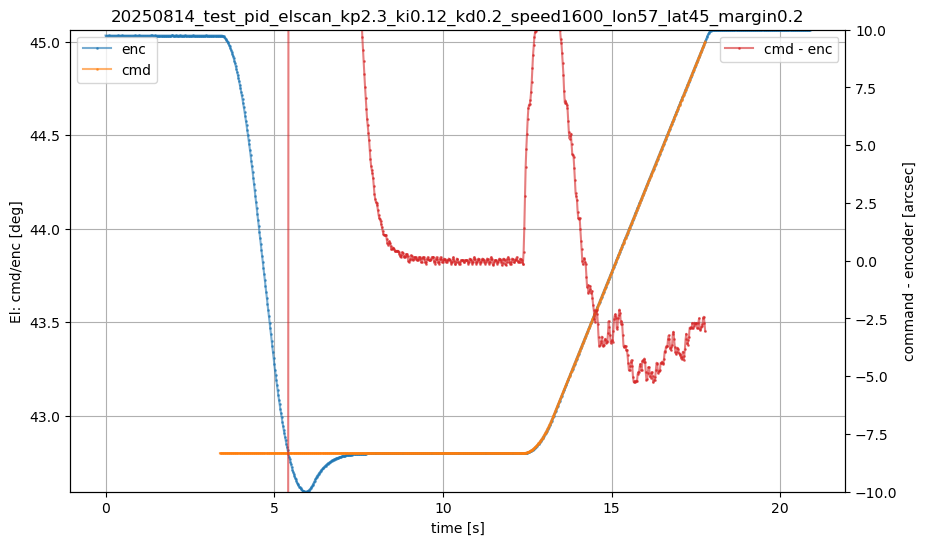

In [418]:
fig_1, ax_1 = plt.subplots(figsize=(10, 6))
ax_r = ax_1.twinx()

ax_1.plot(
    enc_time - relative_zeropoint,
    enc,
    marker=".",
    linestyle="-",
    color="tab:blue",
    label="enc",
    alpha=0.6,
    markersize=2,
)

ax_1.plot(
    cmd_time - relative_zeropoint,
    cmd,
    marker=".",
    linestyle="-",
    color="tab:orange",
    label="cmd",
    alpha=0.6,
    markersize=2,
)

ax_r.plot(
    cmd_time - relative_zeropoint,
    diff*3600,
    color = "tab:red",
    marker=".",
    linestyle="-",
    label="cmd - enc",
    alpha=0.6,
    zorder=0,
    markersize=2,
)

ax_1.legend(loc="upper left")
ax_1.set_title(f"{FILENAME}")
ax_1.set_ylabel("El: cmd/enc [deg]")
ax_1.set_xlabel("time [s]")
ax_1.grid()
# ax_1.axhline(y=42.8)

# 全データまとめてylim計算用に保持
all_x = np.concatenate([enc_time - relative_zeropoint, cmd_time - relative_zeropoint])
all_y = np.concatenate([enc, cmd])

# xlimが変わったらylimを自動調整
def update_ylim(ax):
    xmin, xmax = ax.get_xlim()
    mask = (all_x >= xmin) & (all_x <= xmax)
    if np.any(mask):
        ax.set_ylim(all_y[mask].min(), all_y[mask].max())
        ax.figure.canvas.draw_idle()

ax_1.callbacks.connect('xlim_changed', update_ylim)

# 初期表示のxlim設定
# ax_1.set_xlim(9.2, 9.5)

ax_r.set_ylim(-10, 10)
ax_r.legend(loc="upper right")
ax_r.set_ylabel("command - encoder [arcsec]")
update_ylim(ax_1)  # 初期ylimも合わせる

plt.savefig(save_path_all, dpi=300, bbox_inches="tight")
plt.show()

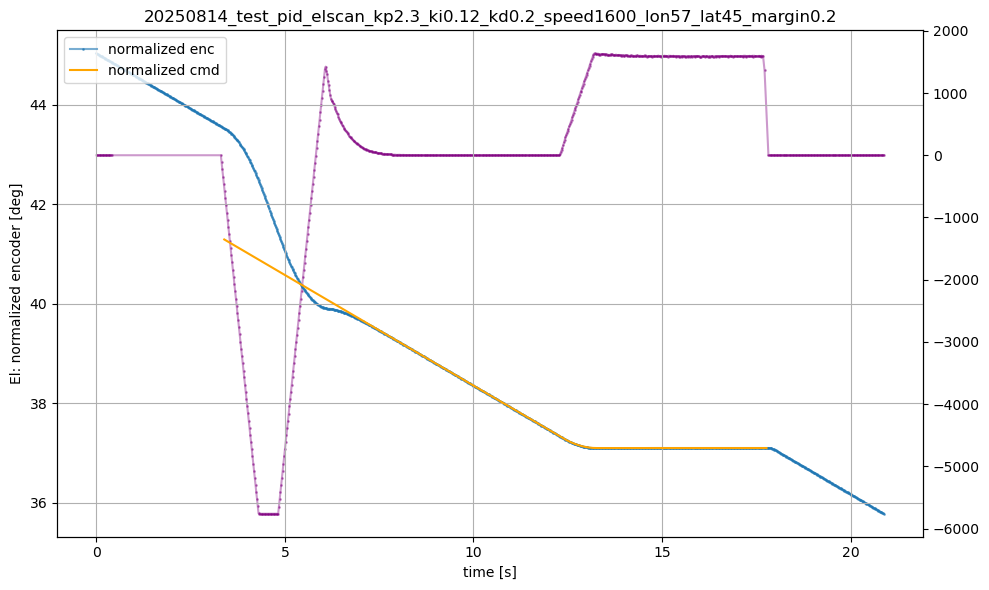

In [419]:
nomalize_num = slope_deg_per_s*3600

# ③ 正規化（コマンド分を引く）
#    60 arcsec/s = (60/3600) deg/s なので、時間差×(60/3600) で補正
enc_norm = enc - (nomalize_num/3600) * (enc_time - relative_zeropoint)
cmd_norm = cmd - (nomalize_num/3600) * (cmd_time - relative_zeropoint)

# ④ プロット
fig, ax = plt.subplots(figsize=(10, 6))
ax_r = ax.twinx()

# エンコーダ／コマンドの正規化値
ax.plot(
    enc_time - relative_zeropoint,
    enc_norm,
    color = "tab:blue",
    marker=".",
    linestyle="-",
    label="normalized enc",
    alpha=0.6,
    zorder=0,
    markersize=2,
)

ax.plot(
    cmd_time - relative_zeropoint,
    cmd_norm,
    color="orange",
    linestyle="-",
    label="normalized cmd",
    alpha=1,
    markersize=2,
)

# 速度コマンド（deg/s → arcsec/s に変換）
ax_r.plot(
    time_sp - relative_zeropoint,
    speed * 3600,
    marker=".",
    linestyle="-",
    color="purple",
    label="speed command",
    alpha=0.4,
    markersize=2,
)

# グリッド＆軸ラベル
ax.grid(True)
ax.set_xlabel("time [s]")
ax.set_ylabel("El: normalized encoder [deg]")


# ① ax を高い zorder (= 手前) に
ax.set_zorder(2)
# ② ax_r を低い zorder (= 奥) に
ax_r.set_zorder(1)
# ③ 背景パッチを透明にして、ax_r の背景が隠れないように
ax.patch.set_visible(False)

# 凡例（label を付けたので handles 指定不要）
ax.legend(loc="upper left")
# ax_r.legend(loc="upper right")

ax.set_title(f"{FILENAME}")

plt.tight_layout()
plt.show()

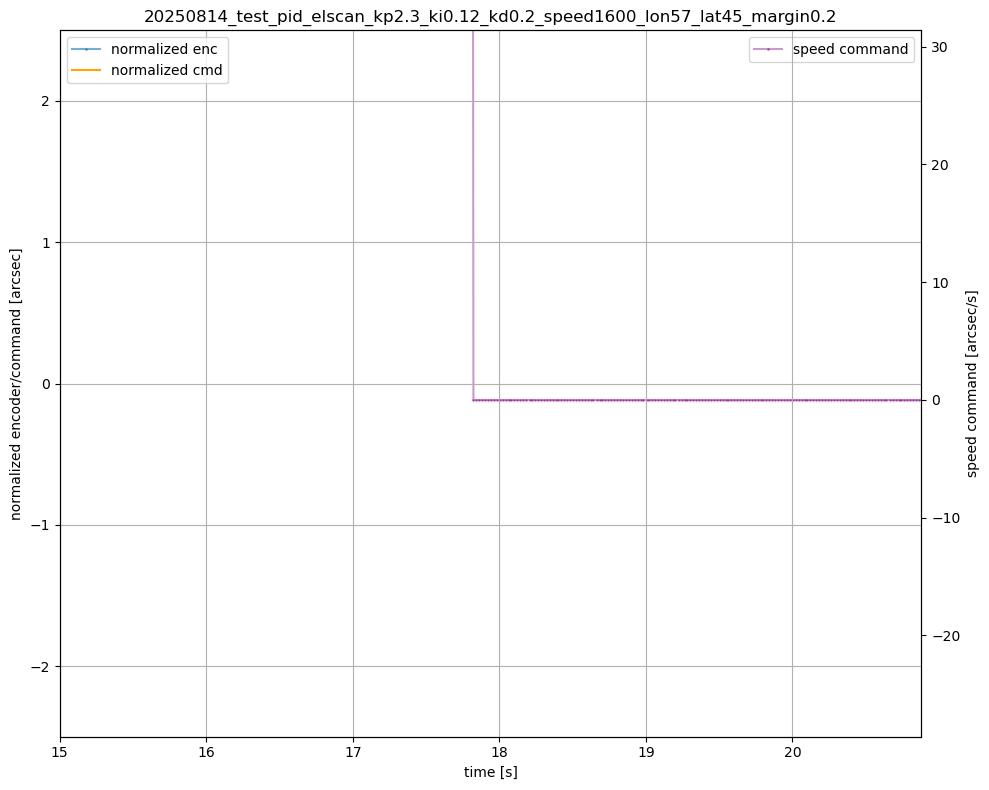

In [420]:
enc_norm -= np.median(cmd_norm)
cmd_norm -= np.median(cmd_norm)

# 相対時刻（秒）とコマンド角度（deg）の ndarray
t_rel = cmd_time - relative_zeropoint  # 既に定義済み

# ④ プロット
fig, ax = plt.subplots(figsize=(10, 8))
ax_r = ax.twinx()

# エンコーダ／コマンドの正規化値
ax.plot(
    enc_time - relative_zeropoint,
    enc_norm*3600,
    color = "tab:blue",
    marker=".",
    linestyle="-",
    label="normalized enc",
    alpha=0.6,
    zorder=0,
    markersize=2,
)

ax.plot(
    cmd_time - relative_zeropoint,
    cmd_norm * 3600,
    color="orange",
    linestyle="-",
    label="normalized cmd",
    alpha=1,
    markersize=2,
)

# 速度コマンド（deg/s → arcsec/s に変換）
ax_r.plot(
    time_sp - relative_zeropoint,
    speed * 3600,
    marker=".",
    linestyle="-",
    color="purple",
    label="speed command",
    alpha=0.4,
    markersize=2,
)

ax.set_xlabel("time [s]")
# ax.set_ylabel("command [deg]")
ax.legend(loc="upper left")

# グリッド＆軸ラベル
ax.grid(True)
ax.set_xlabel("time [s]")
ax.set_ylabel("normalized encoder/command [arcsec]")
ax_r.set_ylabel("speed command [arcsec/s]")

# 軸範囲
point = np.median(enc_norm)
# ax.set_ylim(point-0.011, point+0.011)

# ax_r.set_ylim(slope_deg_per_s*3600*0.8, slope_deg_per_s*3600*1.2)
ax.set_xlim(15, enc_time[-1] - enc_time[0])
ax.set_ylim(-2.5, 2.5)

speed_cmd_med = np.median(speed * 3600,)
ax_r.set_ylim(speed_cmd_med-30, speed_cmd_med+30)

# (ax, ax_r を作ったあと、凡例を描く前などに置く)
# ① ax を高い zorder (= 手前) に
ax.set_zorder(2)
# ② ax_r を低い zorder (= 奥) に
ax_r.set_zorder(1)
# ③ 背景パッチを透明にして、ax_r の背景が隠れないように
ax.patch.set_visible(False)

# 凡例（label を付けたので handles 指定不要）
ax.legend(loc="upper left")
ax_r.legend(loc="upper right")

ax.set_title(f"{FILENAME}")

plt.tight_layout()
plt.show()

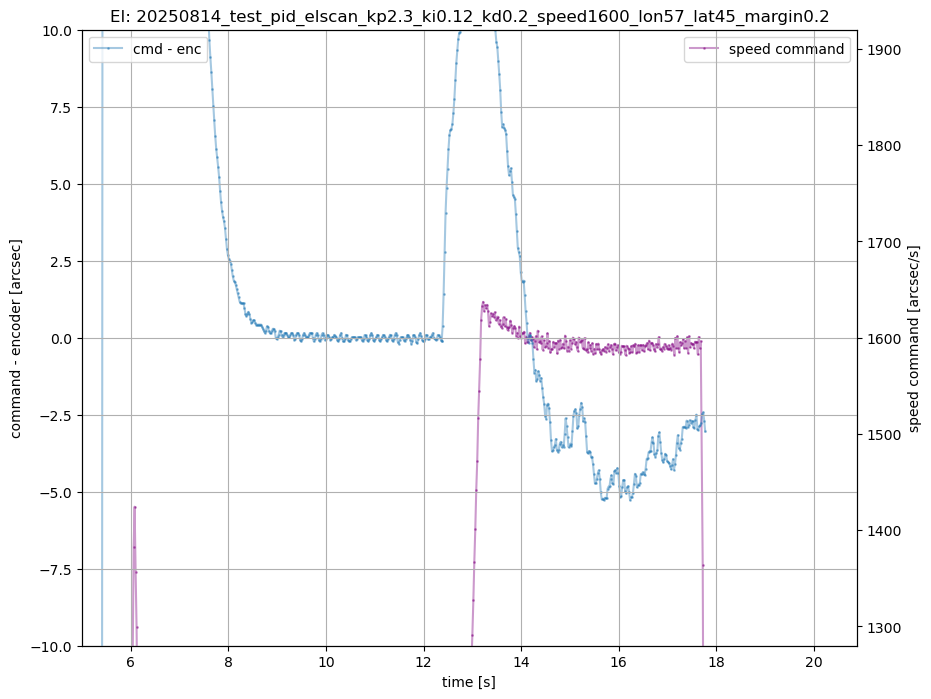

In [421]:
# ④ プロット
fig, ax = plt.subplots(figsize=(10, 8))
ax_r = ax.twinx()

# エンコーダ／コマンドの正規化値
ax.plot(
    cmd_time - relative_zeropoint,
    diff*3600,
    color = "tab:blue",
    marker=".",
    linestyle="-",
    label="cmd - enc",
    alpha=0.4,
    zorder=0,
    markersize=2,
)

# 速度コマンド（deg/s → arcsec/s に変換）
ax_r.plot(
    time_sp - relative_zeropoint,
    speed * 3600,
    marker=".",
    linestyle="-",
    color="purple",
    label="speed command",
    alpha=0.4,
    markersize=2,
)

ax.set_xlabel("time [s]")
# ax.set_ylabel("command [deg]")
ax.legend(loc="upper left")

# グリッド＆軸ラベル
ax.grid(True)
ax.set_xlabel("time [s]")
ax.set_ylabel("command - encoder [arcsec]")
ax_r.set_ylabel("speed command [arcsec/s]")

# 軸範囲
point = np.median(enc_norm)
# ax.set_ylim(point-0.011, point+0.011)

ax_r.set_ylim(slope_deg_per_s*3600*0.8, slope_deg_per_s*3600*1.2)
ax.set_xlim(5, enc_time[-1] - enc_time[0])
ax.set_ylim(-10, 10)

# ax_r.set_ylim(550, 650)

# (ax, ax_r を作ったあと、凡例を描く前などに置く)
# ① ax を高い zorder (= 手前) に
ax.set_zorder(2)
# ② ax_r を低い zorder (= 奥) に
ax_r.set_zorder(1)
# ③ 背景パッチを透明にして、ax_r の背景が隠れないように
ax.patch.set_visible(False)

# 凡例（label を付けたので handles 指定不要）
ax.legend(loc="upper left")
ax_r.legend(loc="upper right")

ax.set_title(f"El: {FILENAME}")

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


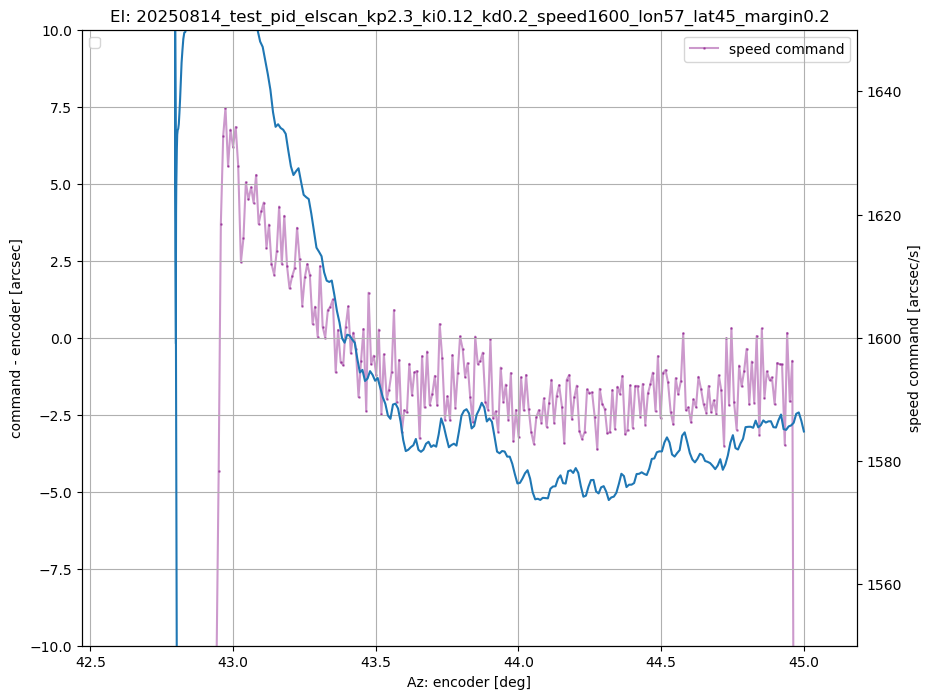

In [422]:
# ④ プロット
fig, ax = plt.subplots(figsize=(10, 8))
ax_r = ax.twinx()
ax.plot(enc_interp, diff*3600)
# エンコーダ／コマンドの正規化値
# ax.plot(
#     enc,
#     diff*3600,
#     color = "tab:blue",
#     marker=".",
#     linestyle="-",
#     label="cmd - enc",
#     alpha=0.4,
#     zorder=0,
#     markersize=2,
# )

# # enc を cmd_time に合わせて補間
# enc_interp = np.interp(cmd_time, enc_time, enc)

enc_interp_sp = np.interp(time_sp, enc_time, enc)

# 速度コマンド（deg/s → arcsec/s に変換）
ax_r.plot(
    enc_interp_sp,
    speed * 3600,
    marker=".",
    linestyle="-",
    color="purple",
    label="speed command",
    alpha=0.4,
    markersize=2,
)

ax.set_xlabel("time [s]")
# ax.set_ylabel("command [deg]")
ax.legend(loc="upper left")

# グリッド＆軸ラベル
ax.grid(True)
ax.set_xlabel("Az: encoder [deg]")
ax.set_ylabel("command - encoder [arcsec]")
ax_r.set_ylabel("speed command [arcsec/s]")

# 軸範囲
point = np.median(enc_norm)
# ax.set_ylim(point-0.011, point+0.011)

# ax_r.set_ylim(slope_deg_per_s*3600*0.8, slope_deg_per_s*3600*1.2)
#ax.set_xlim(5, enc_time[-1] - enc_time[0])
ax.set_ylim(-10, 10)

ax_r.set_ylim(1550, 1650)

# (ax, ax_r を作ったあと、凡例を描く前などに置く)
# ① ax を高い zorder (= 手前) に
ax.set_zorder(2)
# ② ax_r を低い zorder (= 奥) に
ax_r.set_zorder(1)
# ③ 背景パッチを透明にして、ax_r の背景が隠れないように
ax.patch.set_visible(False)

# 凡例（label を付けたので handles 指定不要）
ax.legend(loc="upper left")
ax_r.legend(loc="upper right")

ax.set_title(f"El: {FILENAME}")

# plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [375]:
np.interp(time_sp, enc_time, enc)

array([45.0168178 , 45.01681154, 45.01677966, ..., 45.01345477,
       45.01343224, 45.01346186])